<a href="https://colab.research.google.com/github/nethmi-i-j/Telco-Customer-Churn-Prediction/blob/main/Telco_Customer_Churn_Prediction_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Setup

In [1]:
!pip install optuna -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 4.5 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_validate, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import optuna

from sklearn.metrics import (accuracy_score, recall_score, precision_score, classification_report, f1_score, roc_auc_score)
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import joblib

Configuration

In [3]:
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:.3f}')

CSV_PATH = '/content/WA_Fn-UseC_-Telco-Customer-Churn.csv'
TARGET_COL = 'Churn'
RANDOM_STATE = 42

Load the dataset

In [4]:
df = pd.read_csv(CSV_PATH)

In [5]:
print('Size of the Dataframe : ', df.shape)

Size of the Dataframe :  (7043, 21)


In [6]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.850,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.950,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.850,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.300,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.700,151.65,Yes


In [7]:
# drop CustomerID column

df = df.drop(columns='customerID', axis=1)

In [8]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.850,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.950,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.850,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.300,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.700,151.65,Yes


In [9]:
df['SeniorCitizen'] = df['SeniorCitizen'].map({0:'No', 1:'Yes'})

In [10]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.850,29.85,No
1,Male,No,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.950,1889.5,No
2,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.850,108.15,Yes
3,Male,No,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.300,1840.75,No
4,Female,No,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.700,151.65,Yes


## 2. Exploratory Data Analysis (EDA)

In [11]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   object 
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [13]:
# check for missing values

print('Missing vlues per column : ')
df.isna().sum()

Missing vlues per column : 


,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


* No missing values.

In [14]:
print('Unique values in each column')
for col in df.columns:
  print(f'\n{col} :', df[col].unique())



Unique values in each column

gender : ['Female' 'Male']

SeniorCitizen : ['No' 'Yes']

Partner : ['Yes' 'No']

Dependents : ['No' 'Yes']

tenure : [ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39]

PhoneService : ['No' 'Yes']

MultipleLines : ['No phone service' 'No' 'Yes']

InternetService : ['DSL' 'Fiber optic' 'No']

OnlineSecurity : ['No' 'Yes' 'No internet service']

OnlineBackup : ['Yes' 'No' 'No internet service']

DeviceProtection : ['No' 'Yes' 'No internet service']

TechSupport : ['No' 'Yes' 'No internet service']

StreamingTV : ['No' 'Yes' 'No internet service']

StreamingMovies : ['No' 'Yes' 'No internet service']

Contract : ['Month-to-month' 'One year' 'Two year']

PaperlessBilling : ['Yes' 'No']

PaymentMethod : ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)

* 'TotalCharges' column values stored as strings.

In [15]:
for col in df.columns:
  print('\nTop values:', df[col].value_counts().head(20))


Top values: gender
Male      3555
Female    3488
Name: count, dtype: int64

Top values: SeniorCitizen
No     5901
Yes    1142
Name: count, dtype: int64

Top values: Partner
No     3641
Yes    3402
Name: count, dtype: int64

Top values: Dependents
No     4933
Yes    2110
Name: count, dtype: int64

Top values: tenure
1     613
72    362
2     238
3     200
4     176
71    170
5     133
7     131
8     123
9     119
70    119
12    117
10    116
6     110
13    109
68    100
11     99
15     99
67     98
18     97
Name: count, dtype: int64

Top values: PhoneService
Yes    6361
No      682
Name: count, dtype: int64

Top values: MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

Top values: InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

Top values: OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64

* there are 11 invalid values stored as ' ' in Total Charges column.

In [16]:
df[df['TotalCharges']==' ']

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,No,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.550,,No
753,Male,No,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.250,,No
936,Female,No,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.850,,No
1082,Male,No,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.750,,No
1340,Female,No,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.050,,No
3331,Male,No,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.850,,No
3826,Male,No,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.350,,No
4380,Female,No,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.000,,No
5218,Male,No,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.700,,No
6670,Female,No,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.350,,No


* Since tenure is 0 also TotalCharges should be 0. Hence these data records are meanigful. So replaces the ' ' with 0.

In [17]:
df['TotalCharges'] = df['TotalCharges'].replace({' ':'0.0'})

In [18]:
df['TotalCharges'] = df['TotalCharges'].astype(float)

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   object 
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [20]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
tenure,7043.000,32.371,24.559,0.000,9.000,29.000,55.000,72.000
MonthlyCharges,7043.000,64.762,30.090,18.250,35.500,70.350,89.850,118.750
TotalCharges,7043.000,2279.734,2266.794,0.000,398.550,1394.550,3786.600,8684.800


In [21]:
# class distribution of target column

df[TARGET_COL].value_counts()

,count
Churn,
No,5174
Yes,1869


* The dataset is imbalanced

In [22]:
numerical_columns = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_columns = df.select_dtypes(exclude=[np.number]).columns.tolist()

print('Numerical Columns : ',numerical_columns)
print('Categorical Columns :' , categorical_columns)
print('Target : ',TARGET_COL)

Numerical Columns :  ['tenure', 'MonthlyCharges', 'TotalCharges']
Categorical Columns : ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']
Target :  Churn


## 3. Data Visualization

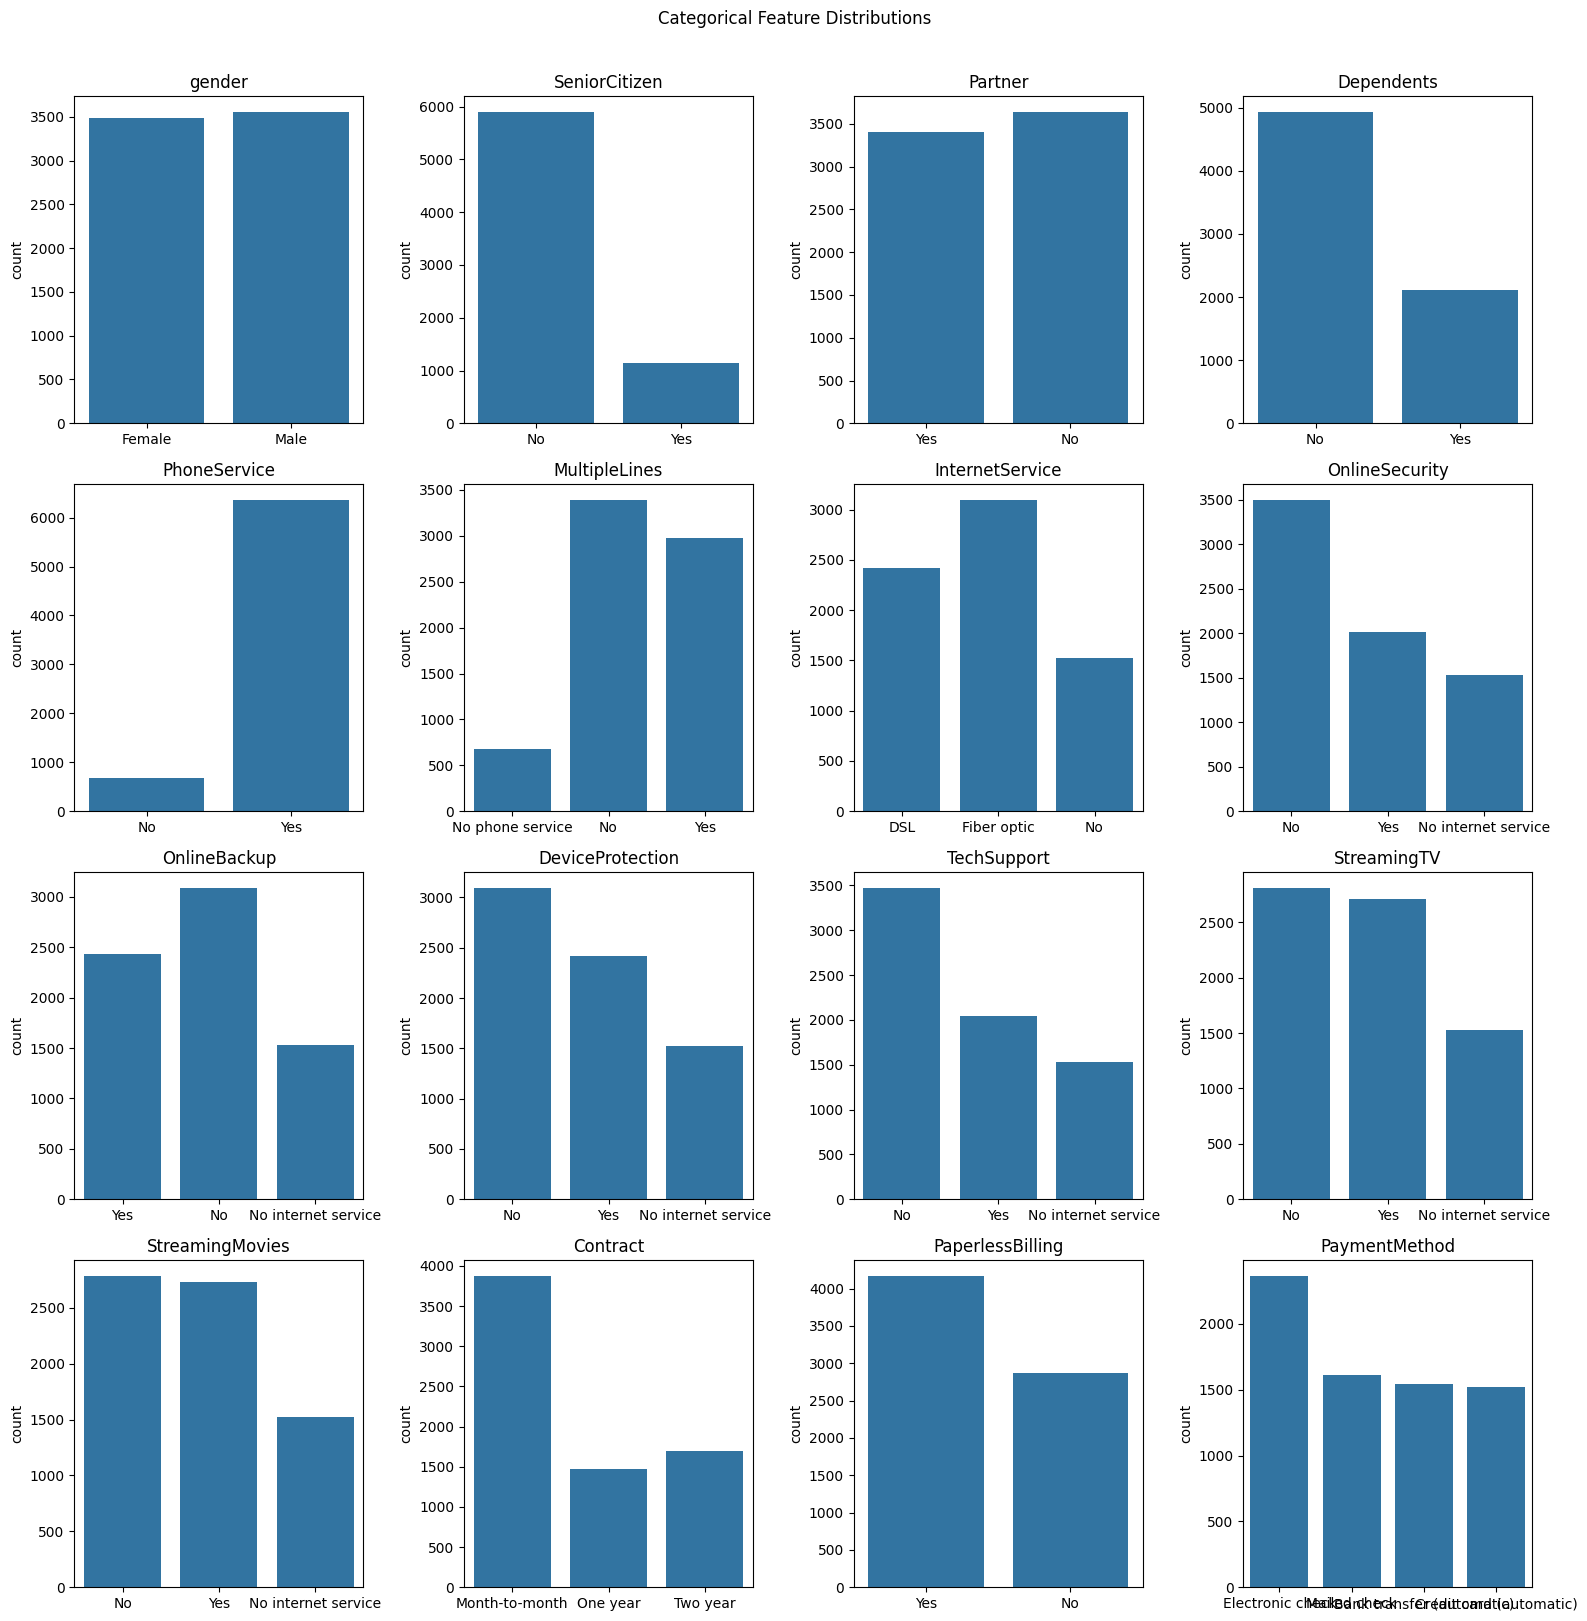

In [23]:
# count plots for categorical columns

fig, axes = plt.subplots(4, 4, figsize=(16, 16))
axes = axes.flatten()

for i, col in enumerate(df[['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']]):
    sns.countplot(x=col, data=df, ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x')


plt.suptitle('Categorical Feature Distributions', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

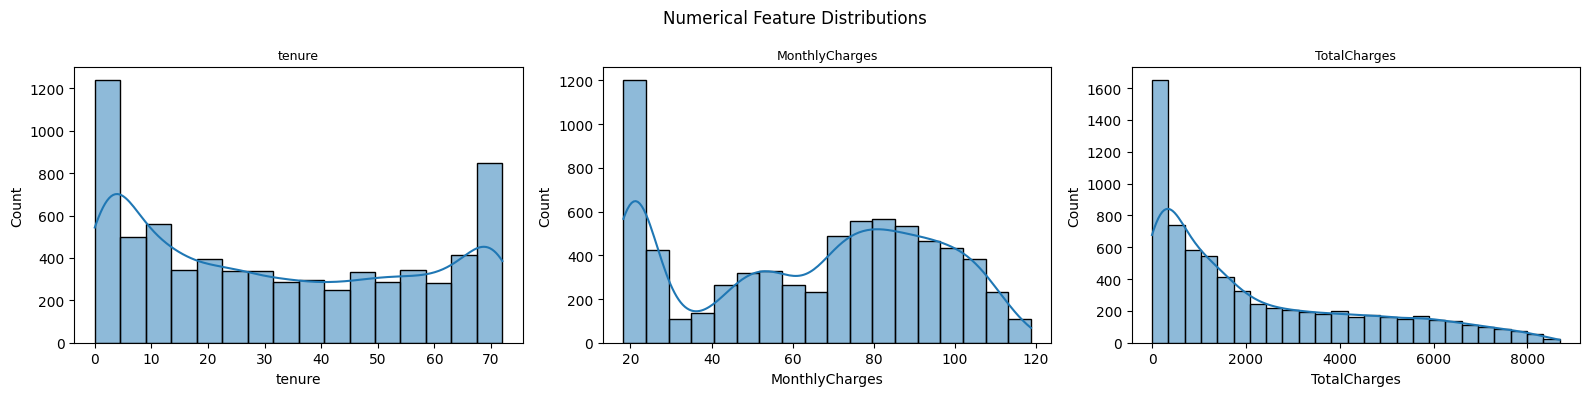

In [24]:
# histograms for numerical features

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes = axes.flatten()

for i, col in enumerate(numerical_columns):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(col, fontsize=9)

plt.suptitle('Numerical Feature Distributions', fontsize=12)
plt.tight_layout()
plt.show()

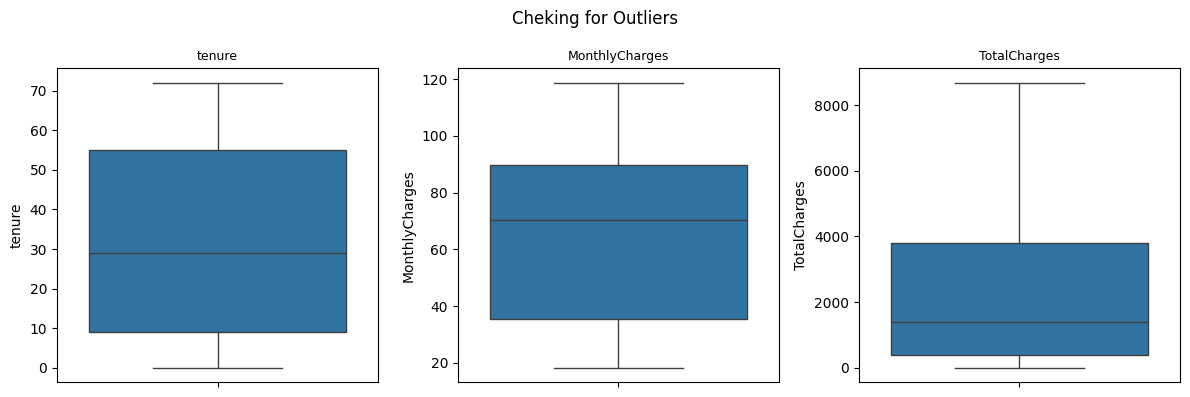

In [25]:
# boxplots for identify outliers

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes = axes.flatten()

for i, col in enumerate(numerical_columns):
    sns.boxplot(df[col], ax=axes[i])
    axes[i].set_title(col, fontsize=9)

plt.suptitle('Cheking for Outliers', fontsize=12)
plt.tight_layout()
plt.show()

* No outliers.

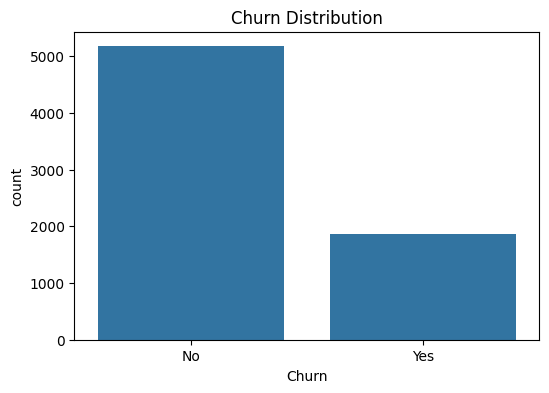

In [26]:
# Target Distribution

plt.figure(figsize=(6,4))
sns.countplot(x=df[TARGET_COL], data=df)
plt.title('Churn Distribution')
plt.xlabel('Churn')
plt.show()

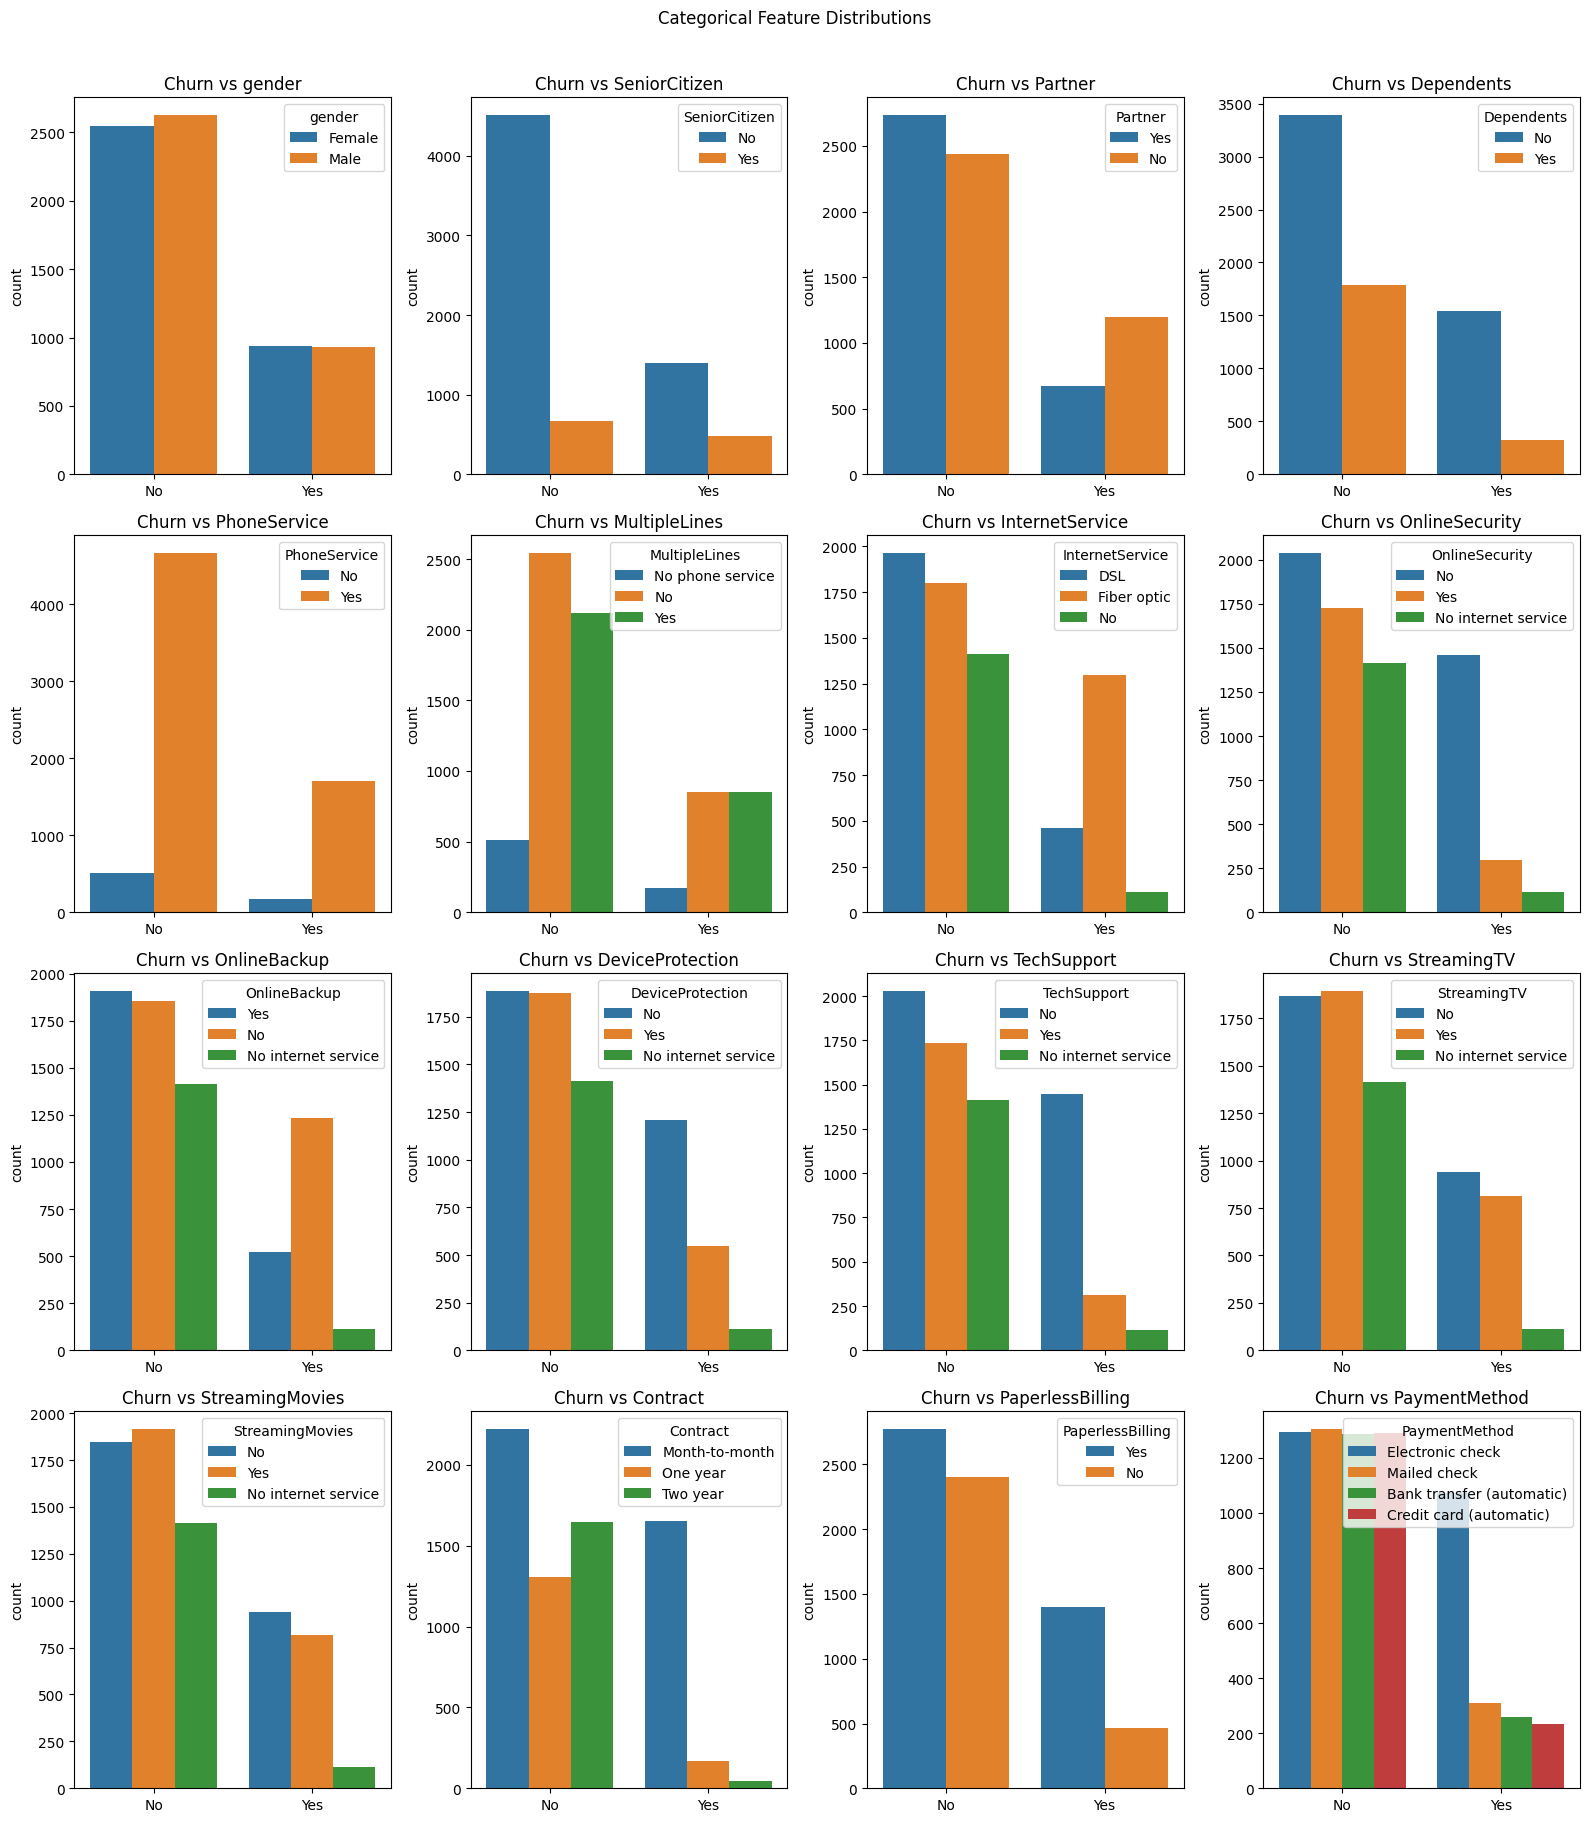

In [27]:
fig, axes = plt.subplots(4, 4, figsize=(16, 18))
axes = axes.flatten()

for i, col in enumerate(df[['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']]):
    sns.countplot(x=TARGET_COL, hue=col, data=df, ax=axes[i])
    axes[i].set_title(f'Churn vs {col}')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x')

#fig.delaxes(axes[])
plt.suptitle('Categorical Feature Distributions', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

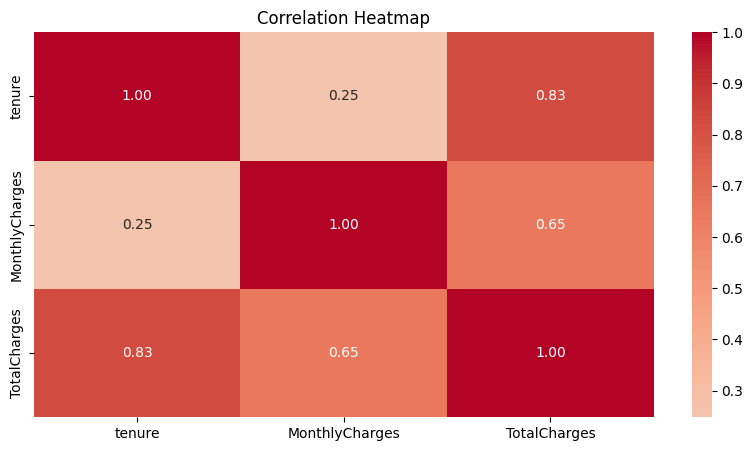

In [28]:
plt.figure(figsize=(10,5))
sns.heatmap(df[['tenure','MonthlyCharges', 'TotalCharges']].corr(), center=0, fmt='.2f', annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [29]:
#  VIF Check for Multicollinearity

vif_df = pd.DataFrame()
vif_df['Feature'] = numerical_columns
vif_df['VIF'] = [
    variance_inflation_factor(df[numerical_columns].values, i)
    for i in range(len(numerical_columns))
]

print(vif_df.sort_values('VIF', ascending=False))

          Feature   VIF
2    TotalCharges 8.075
0          tenure 6.332
1  MonthlyCharges 3.356


**Key Insights from EDA**

* There are 3 numerical features and 16 categorical features.

* Removed Customer ID column because it is not required for modeling.
* There are no missing values.
* Replaced 11 invalid ' ' values to 0 because it is meaningful.
* the dataset is imbalanced with 5174 'No' values and 1869 'Yes' values in target column (churn).
* Since VIF values >5 for tenure and TotalChargs there is a multicolinearity.

**Preprocessing and Evaluation Plan**

* preprocessing pipeline to avoid data leakage.
* cross validation(CV)---> model selection ---> hyperparameter tuning (optuna)
---> Evaluation ---> predictive system



## 4. Data Preprocessing

In [30]:
df['Churn'] = df['Churn'].replace({'Yes':1, 'No':0})

/tmp/ipykernel_4637/2767291496.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Churn'] = df['Churn'].replace({'Yes':1, 'No':0})


In [31]:
X = df.drop(columns='Churn')
Y = df['Churn']

In [32]:
X.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.850,29.850
1,Male,No,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.950,1889.500
2,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.850,108.150
3,Male,No,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.300,1840.750
4,Female,No,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.700,151.650


In [33]:
Y.head()

,Churn
0,0
1,0
2,1
3,0
4,1


In [34]:
df[TARGET_COL].value_counts()

,count
Churn,
0,5174
1,1869


In [35]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=RANDOM_STATE)


In [36]:
print(X_train.shape)
print(X_test.shape)

(5634, 19)
(1409, 19)


In [37]:
print(Y_train.value_counts())

Churn
0    4139
1    1495
Name: count, dtype: int64


Preprocessing Pipeline

In [38]:

num_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_features = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

print('numerical features : ', num_features)
print('categorical_features : ', cat_features)

numerical_transformer = Pipeline(
    steps=[
        ('impute',SimpleImputer(strategy='median')),
        ('scale',StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ('impute',SimpleImputer(strategy='most_frequent')),
        ('encode',OneHotEncoder(handle_unknown='ignore'))
    ]
)

preprocess = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, num_features),
        ('cat', categorical_transformer, cat_features)
    ]
)

numerical features :  ['tenure', 'MonthlyCharges', 'TotalCharges']
categorical_features :  ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


* Synthetic Minority Oversampling Technique (SMOTE) ---> Automatically identifies minority class (1) and oversample it such that it also have equal number of value count like as majority class.

## 5. Model Selection

In [39]:
models = {
    'Decision Tree': DecisionTreeClassifier(random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(random_state=RANDOM_STATE),
    'XGBoost': XGBClassifier(random_state=RANDOM_STATE)

}

In [40]:
k = 5
cv = StratifiedKFold(n_splits=k, shuffle=True, random_state=RANDOM_STATE)

In [41]:
scoring = {
    'accuracy'          : 'accuracy',
    'f1'                : 'f1',
    'precision'         : 'precision',
    'recall'            : 'recall',
    'roc_auc'           : 'roc_auc'

}

In [42]:
rows = []

for name, model in models.items():

    pipe = ImbPipeline(
        steps=[
            ('preprocess', preprocess),
            ('smote',SMOTE(random_state=RANDOM_STATE)),
            ('model', model)
        ]
    )

    scores = cross_validate(
        pipe,
        X_train,
        Y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    rows.append({
        'Model': name,

        'Accuracy': scores['test_accuracy'].mean(),
        'F1': scores['test_f1'].mean(),
        'Precision': scores['test_precision'].mean(),
        'Recall': scores['test_recall'].mean(),
        'ROC-AUC' : scores['test_roc_auc'].mean()


    })

cv_results = pd.DataFrame(rows).sort_values(by='F1', ascending=False)

In [43]:
print("=== CV Model Comparison ===")

print(cv_results)

=== CV Model Comparison ===
           Model  Accuracy    F1  Precision  Recall  ROC-AUC
2        XGBoost     0.782 0.577      0.595   0.562    0.824
1  Random Forest     0.779 0.572      0.590   0.555    0.818
0  Decision Tree     0.721 0.497      0.477   0.520    0.657


In [44]:
cv_results

,Model,Accuracy,F1,Precision,Recall,ROC-AUC
2,XGBoost,0.782,0.577,0.595,0.562,0.824
1,Random Forest,0.779,0.572,0.590,0.555,0.818
0,Decision Tree,0.721,0.497,0.477,0.520,0.657


* Since XGBoostClasifier got the highest metrics values  rather than RandomForestClassifier and DecisionTreeClassifier XGBoost was chosen as model to be tunned with range of parameters using Optuna Python Library.

Hyperparameter Tunning

In [54]:
def objective(trial):

    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 300, 800),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.2),
        'max_depth':         trial.suggest_int('max_depth', 3, 10),
        'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight':  trial.suggest_int('min_child_weight', 1, 10),
        'gamma':             trial.suggest_float('gamma', 0.0, 5.0),
        'reg_alpha':         trial.suggest_float('reg_alpha', 0.0, 5.0),
        'reg_lambda':        trial.suggest_float('reg_lambda', 0.0, 5.0),
    }

    xg_pipe = ImbPipeline(steps=[
        ('preprocess', preprocess),
        ('smote', SMOTE(random_state=RANDOM_STATE)),
        ('model', XGBClassifier(
            **params,
            random_state=RANDOM_STATE,
            eval_metric='logloss'
        ))
    ])


    scores = cross_val_score(
        xg_pipe, X_train, Y_train,
        cv=cv,
        scoring='f1',
        n_jobs=-1
    )
    return scores.mean()


# --- Run the study ---
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, show_progress_bar=True)

# --- Results ---
print("Best F1_Score:", study.best_value)
print("Best params: ", study.best_params)

[I 2026-06-19 05:10:46,556] A new study created in memory with name: no-name-c09f9806-bd88-4fb0-a028-eb239b830fb3


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-06-19 05:10:51,165] Trial 0 finished with value: 0.6197284812785518 and parameters: {'n_estimators': 635, 'learning_rate': 0.17113105761151354, 'max_depth': 8, 'subsample': 0.7946837443761965, 'colsample_bytree': 0.6480448862213349, 'min_child_weight': 3, 'gamma': 3.635797694860257, 'reg_alpha': 0.7711040501122401, 'reg_lambda': 0.25331169344381954}. Best is trial 0 with value: 0.6197284812785518.
[I 2026-06-19 05:10:52,815] Trial 1 finished with value: 0.6332003867090584 and parameters: {'n_estimators': 319, 'learning_rate': 0.1551847364574354, 'max_depth': 4, 'subsample': 0.9946072077150766, 'colsample_bytree': 0.520939099116186, 'min_child_weight': 4, 'gamma': 3.942913606195149, 'reg_alpha': 1.5725319429246976, 'reg_lambda': 2.0247737475470045}. Best is trial 1 with value: 0.6332003867090584.
[I 2026-06-19 05:10:55,554] Trial 2 finished with value: 0.6348164262437387 and parameters: {'n_estimators': 446, 'learning_rate': 0.1512943095805869, 'max_depth': 6, 'subsample': 0.598

In [55]:
best_pipe = ImbPipeline(steps=[
    ('preprocess', preprocess),
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    ('model', XGBClassifier(
        **study.best_params,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        eval_metric='logloss'
    ))
])

best_pipe.fit(X_train, Y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  ['tenure', 'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('cat',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encode',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender', 'SeniorCitiz...
                               gamma=4.103497641413877, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None,
                               learning_rate=0.041092957329253235, max_bin=None,
                               max_cat_threshold=None, max_cat_to_onehot=None,
                               max_delta_step=None, max_depth=5,
                               max_leaves=None, min_child_weight=6, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=370, n_jobs=-1,
                               num_parallel_tree=None, ...))])

In [56]:
train_pred  = best_pipe.predict(X_train)
test_pred   = best_pipe.predict(X_test)
train_proba = best_pipe.predict_proba(X_train)[:, 1]
test_proba  = best_pipe.predict_proba(X_test)[:, 1]

print("=== Final Evaluation — Tuned XGBoost Classifier ===\n")

print("Training")
print("--------")
print(f"Accuracy  : {accuracy_score(Y_train, train_pred):.4f}")
print(f"Precision : {precision_score(Y_train, train_pred):.4f}")
print(f"Recall    : {recall_score(Y_train, train_pred):.4f}")
print(f"F1        : {f1_score(Y_train, train_pred):.4f}")
print(f"ROC-AUC   : {roc_auc_score(Y_train, train_proba):.4f}")

print("\nTesting")
print("-------")
print(f"Accuracy  : {accuracy_score(Y_test, test_pred):.4f}")
print(f"Precision : {precision_score(Y_test, test_pred):.4f}")
print(f"Recall    : {recall_score(Y_test, test_pred):.4f}")
print(f"F1        : {f1_score(Y_test, test_pred):.4f}")
print(f"ROC-AUC   : {roc_auc_score(Y_test, test_proba):.4f}")


print("\nClassification Report")
print("---------------------")
print(classification_report(Y_test, test_pred, target_names=['No Churn', 'Churn']))

=== Final Evaluation — Tuned XGBoost Classifier ===

Training
--------
Accuracy  : 0.8026
Precision : 0.6083
Recall    : 0.7197
F1        : 0.6593
ROC-AUC   : 0.8655

Testing
-------
Accuracy  : 0.7757
Precision : 0.5625
Recall    : 0.6979
F1        : 0.6229
ROC-AUC   : 0.8452

Classification Report
---------------------
              precision    recall  f1-score   support

    No Churn       0.88      0.80      0.84      1035
       Churn       0.56      0.70      0.62       374

    accuracy                           0.78      1409
   macro avg       0.72      0.75      0.73      1409
weighted avg       0.80      0.78      0.78      1409



In [57]:
## 8. Threshold Tuning

proba = best_pipe.predict_proba(X_test)[:, 1]

print('Threshold Tuning for XGBoost')
print('-' * 44)
print(f'{"Thresh":<10}{"Precision":<12}{"Recall":<10}{"F1":<8}')
print('-' * 44)

for thresh in [0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:
    preds = (proba >= thresh).astype(int)
    prec  = precision_score(Y_test, preds, pos_label=1)
    rec   = recall_score(Y_test, preds, pos_label=1)
    f1    = f1_score(Y_test, preds, pos_label=1)
    print(f'{thresh:<10}{prec:<12.3f}{rec:<10.3f}{f1:<8.3f}')

print('-' * 44)

Threshold Tuning for XGBoost
--------------------------------------------
Thresh    Precision   Recall    F1      
--------------------------------------------
0.25      0.465       0.877     0.608   
0.3       0.486       0.850     0.619   
0.35      0.506       0.813     0.624   
0.4       0.533       0.781     0.633   
0.45      0.546       0.743     0.630   
0.5       0.562       0.698     0.623   
--------------------------------------------


* **At threshold 0.4, the model achieves 53% precision and 78.1% recall, making it suitable for cost-intensive retention campaigns by minimizing false positives while retaining strong churner coverage.**

In [58]:
threshold = 0.4
Y_pred = (proba >= threshold).astype(int)


In [62]:
print(classification_report(Y_test, Y_pred, target_names=('No Churn', 'Churn'), digits=3))

              precision    recall  f1-score   support

    No Churn      0.905     0.753     0.822      1035
       Churn      0.533     0.781     0.633       374

    accuracy                          0.760      1409
   macro avg      0.719     0.767     0.728      1409
weighted avg      0.806     0.760     0.772      1409



In [63]:
# Apply Best Threshold

y_pred_tuned = (test_proba >= threshold).astype(int)

print("\n=== Evaluation with Tuned Threshold ===\n")
print(f"Threshold  : {threshold:.4f}")
print(f"Accuracy   : {accuracy_score(Y_test, y_pred_tuned):.4f}")
print(f"Precision  : {precision_score(Y_test, y_pred_tuned):.4f}")
print(f"Recall     : {recall_score(Y_test, y_pred_tuned):.4f}")
print(f"F1         : {f1_score(Y_test, y_pred_tuned):.4f}")
print(f"ROC-AUC    : {roc_auc_score(Y_test, test_proba):.4f}")

print("\nClassification Report")
print("---------------------")
print(classification_report(Y_test, y_pred_tuned, target_names=['No Churn', 'Churn']))


=== Evaluation with Tuned Threshold ===

Threshold  : 0.4000
Accuracy   : 0.7601
Precision  : 0.5328
Recall     : 0.7807
F1         : 0.6334
ROC-AUC    : 0.8452

Classification Report
---------------------
              precision    recall  f1-score   support

    No Churn       0.90      0.75      0.82      1035
       Churn       0.53      0.78      0.63       374

    accuracy                           0.76      1409
   macro avg       0.72      0.77      0.73      1409
weighted avg       0.81      0.76      0.77      1409



**Final Evaluation Results at Threshold=0.4**

* Accuracy   : 76.0%
* Precision  : 53.3%
* Recall     : 78.1%
* F1         : 63.34%
* ROC-AUC    : 84.5%



Confusion Matrix
[[779 256]
 [ 82 292]]


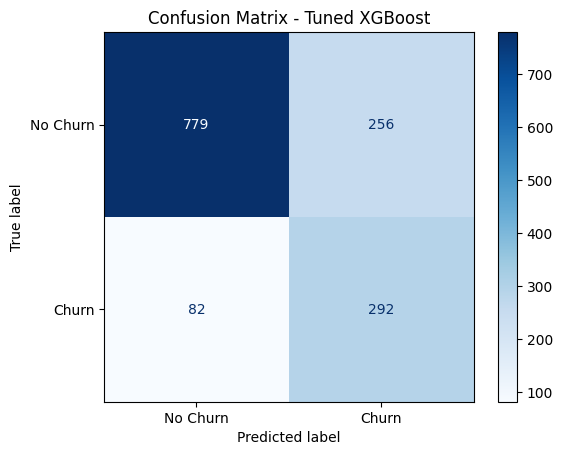

In [64]:
cm = confusion_matrix(Y_test, y_pred_tuned)

print("Confusion Matrix")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['No Churn', 'Churn']
)

disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Tuned XGBoost')
plt.show()

<Axes: >

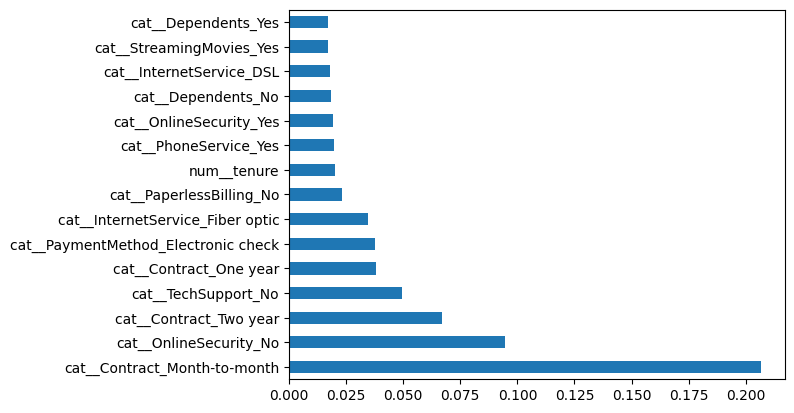

In [65]:
feature_names = (best_pipe.named_steps['preprocess'].get_feature_names_out())
importances = best_pipe.named_steps['model'].feature_importances_
pd.Series(importances, index=feature_names).nlargest(15).plot(kind='barh')

* **This shows shorter contract period highly influence on customer chrnning.**

## 6. Save and download the model

In [66]:
MODEL_PATH = 'telco_customer_churn_xgboost_model.joblib'
joblib.dump(best_pipe, MODEL_PATH)
print(f'Model saved to {MODEL_PATH}')

Model saved to telco_customer_churn_xgboost_model.joblib


In [67]:
# Verify the saved model

loaded_model = joblib.load(MODEL_PATH)


Predictive System

In [68]:
def predict_churn(
    gender, SeniorCitizen, Partner, Dependents, tenure,
    PhoneService, MultipleLines, InternetService, OnlineSecurity,
    OnlineBackup, DeviceProtection, TechSupport, StreamingTV,
    StreamingMovies, Contract, PaperlessBilling, PaymentMethod,
    MonthlyCharges, TotalCharges
):
    input_data = pd.DataFrame([{
        'gender'          : gender,
        'SeniorCitizen'   : SeniorCitizen,
        'Partner'         : Partner,
        'Dependents'      : Dependents,
        'tenure'          : tenure,
        'PhoneService'    : PhoneService,
        'MultipleLines'   : MultipleLines,
        'InternetService' : InternetService,
        'OnlineSecurity'  : OnlineSecurity,
        'OnlineBackup'    : OnlineBackup,
        'DeviceProtection': DeviceProtection,
        'TechSupport'     : TechSupport,
        'StreamingTV'     : StreamingTV,
        'StreamingMovies' : StreamingMovies,
        'Contract'        : Contract,
        'PaperlessBilling': PaperlessBilling,
        'PaymentMethod'   : PaymentMethod,
        'MonthlyCharges'  : MonthlyCharges,
        'TotalCharges'    : TotalCharges
    }])

    proba = loaded_model.predict_proba(input_data)[:, 1]
    prediction = (proba >= 0.35).astype(int)

    print(f"Churn Probability : {proba[0]:.4f}")
    print(f"Prediction        : {'Churn' if prediction[0] == 1 else 'No Churn'}")



In [69]:
predict_churn(
    gender='Female',
    SeniorCitizen='No',
    Partner='Yes',
    Dependents='No',
    tenure=1,
    PhoneService='No',
    MultipleLines='No phone service',
    InternetService='DSL',
    OnlineSecurity='No',
    OnlineBackup='Yes',
    DeviceProtection='No',
    TechSupport='No',
    StreamingTV='No',
    StreamingMovies='No',
    Contract='Month-to-Month',
    PaperlessBilling='Yes',
    PaymentMethod='Electronic check',
    MonthlyCharges=29.85,
    TotalCharges=29.85


)

Churn Probability : 0.3310
Prediction        : No Churn
